# Shallow Methods of Predicting Oral Health from SES

## Three tasks
| Num | Target | ML Task |
|---|---|---|
| 1 | `target_poor_selfrated`:  patient rates their oral health as Fair or Poor | Binary classification |
| 2 | `target_needs_care`: clinician recommends any level of dental care | Binary classification |
| 3 | `dmft_score`: total Decayed + Missing + Filled teeth | Regression |

## Models
Logistic Regression, Linear Regression with Ridge, Random Forest, and XGBoost. All with 5-fold cross-validation.

## Data cleaning
The features used still had some unhelpful NHANES codes (7, 9, 77, 99 all represent "don't know", or declined to answer) and logical encoding problems where 1=yes/2=no.

In [38]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 123
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded')

Libraries loaded


## 1. Load Data

In [12]:
DATA_PATH = 'data/processed/nhanes_model_ready_revise.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

## 2. Data Cleaning

The audit found several categories of errors that must be fixed before any features are used in a model.

In [13]:
df = df_raw.copy()

# replace unhelpful codes of refused/don't know with NaN 
df['race_ethnicity_detailed'] = df['race_ethnicity_detailed'].replace({7: np.nan})

# country_of_birth -> 77=refused, 99=don't know
df['country_of_birth'] = df['country_of_birth'].replace({77: np.nan, 99: np.nan})

# reason_last_dental_visit -> 7=refused, 9=don't know
df['reason_last_dental_visit'] = df['reason_last_dental_visit'].replace({7: np.nan, 9: np.nan})

# needed_dental_care_couldnt_get -> 9=don't know
df['needed_dental_care_couldnt_get'] = df['needed_dental_care_couldnt_get'].replace({9: np.nan})

# freq columns -> 9=don't know
for col in ['freq_mouth_aching_past_year', 'freq_job_difficulty_from_mouth', 'freq_embarrassed_from_mouth']:
    df[col] = df[col].replace({9: np.nan})

# questionnaire yes/no columns -> 7=refused, 9=don't know
for col in ['had_gum_disease_treatment', 'thinks_has_gum_disease', 'had_oral_cancer_exam']:
    df[col] = df[col].replace({9: np.nan})
df['told_bone_loss_around_teeth'] = df['told_bone_loss_around_teeth'].replace({7: np.nan, 9: np.nan})

print('7 and 9 codes replaced with NaN')

# NHANES used 1=yes / 2=no
# Need to recode to 1=yes / 0=no 
# Otherwise, these as 1 and 2 means a model treats 'no' as twice the value of 'yes'
yes_no_cols = [
    'needed_dental_care_couldnt_get',
    'had_gum_disease_treatment',
    'thinks_has_gum_disease',
    'told_bone_loss_around_teeth',
    'had_oral_cancer_exam',
]
for col in yes_no_cols:
    df[col] = df[col].replace({1: 1, 2: 0}) # 1=yes stays 1, 2=no becomes 0
print(f'Recoded {len(yes_no_cols)} yes/no columns from 1/2 to 1/0')

# floss_days_past_week had floating point zero and 9=don't know codes
df['floss_days_past_week'] = df['floss_days_past_week'].replace({9: np.nan})
df['floss_days_past_week'] = df['floss_days_past_week'].apply(
    lambda x: 0.0 if (pd.notna(x) and abs(x) < 1e-10) else x
)

7 and 9 codes replaced with NaN
Recoded 5 yes/no columns from 1/2 to 1/0


In [14]:
#  just confirming no bad codes remain in cleaned columns 
code_checks = {
    'race_ethnicity_detailed': [7],
    'country_of_birth': [77, 99],
    'reason_last_dental_visit': [7, 9],
    'needed_dental_care_couldnt_get': [9],
    'freq_mouth_aching_past_year': [9],
    'had_gum_disease_treatment': [9],
    'thinks_has_gum_disease': [9],
    'told_bone_loss_around_teeth': [7, 9],
    'had_oral_cancer_exam': [9],
    'floss_days_past_week': [9],
}

# debugging
errors = []
for col, codes in code_checks.items():
    for code in codes:
        n = (df[col] == code).sum()
        if n > 0:
            errors.append(f'{col}: code {code} still present ({n} rows)')

if errors:
    print('CODE ERRORS:')
    for e in errors:
        print(f'{e}')
else:
    print('No unhelpful codes remain.')

print('\nVerify yes/no cols are recoded correctly:')
for col in yes_no_cols:
    vals = sorted(df[col].dropna().unique())
    status = 'OK' if set(vals) <= {0, 1} else 'ERROR'
    print(f'{col}: {vals} [{status}]')


print(f'\nfloss_days_past_week min: {df["floss_days_past_week"].min():.4g} (should be 0.0)')
print(f'floss_days_past_week max: {df["floss_days_past_week"].max():.4g} (should be 7.0)')

No unhelpful codes remain.

Verify yes/no cols are recoded correctly:
needed_dental_care_couldnt_get: [np.float64(0.0), np.float64(1.0)] [OK]
had_gum_disease_treatment: [np.float64(0.0), np.float64(1.0)] [OK]
thinks_has_gum_disease: [np.float64(0.0), np.float64(1.0)] [OK]
told_bone_loss_around_teeth: [np.float64(0.0), np.float64(1.0)] [OK]
had_oral_cancer_exam: [np.float64(0.0), np.float64(1.0)] [OK]

floss_days_past_week min: 0 (should be 0.0)
floss_days_past_week max: 7 (should be 7.0)


## 3. Feature Sets

Features are grouped by type. Each task uses a different subset to avoid data leakage.
- `target_poor_selfrated` is engineered from `self_rated_oral_health` so that column can't be a feature for Task 1
- `freq_mouth_aching_past_year`, `freq_job_difficulty_from_mouth`, `freq_embarrassed_from_mouth` all measure oral health quality of life from the same questionnaire as `self_rated_oral_health`. To include them for Task 1 would be redundent together and inflate the model. The essentially measuring the same thing.
- For Task 3 (dmft_score regression), dental features derived from the same exam (teeth_present, treatment_ratio, etc.) shouldn't be additional predictors. It would be data leakage and the model would essentially be cheating.

In [15]:
# SES features income_poverty_ratio is used instead of household_income/family_income
# bc it's continuous and those two columns highly correlate
SES = ['income_poverty_ratio', 'education_adult']

DEMO = ['age', 'gender', 'race_ethnicity', 'marital_status', 'household_size', 'country_of_birth']

ACCESS = [
    'last_dental_visit',
    'reason_last_dental_visit',
    'needed_dental_care_couldnt_get',
    'barrier_cost',
    'barrier_insurance_no_coverage',
    'barrier_cant_take_time_off_work',
    'barrier_too_busy',
    'barrier_office_too_far',
    'barrier_afraid_of_dentist',
    'barrier_didnt_want_to_spend',
    'barrier_other',
]

BEHAVIORAL = [
    'floss_days_past_week',
    'had_gum_disease_treatment',
    'had_oral_cancer_exam',
]

# Self-reported oral health symptoms are excluded from Task 1 because they are biased
# We will include them for Task 2 and Task 3 since they are relevant predictors of the
# targets and not circular predictors from the same exam
SELF_REPORT = [
    'thinks_has_gum_disease',
    'told_bone_loss_around_teeth',
    'freq_mouth_aching_past_year',
    'freq_job_difficulty_from_mouth',
    'freq_embarrassed_from_mouth',
    'self_rated_oral_health',
]

# Clinical dental measures from the exam
CLINICAL = [
    'dmft_score', # excluded for Task 3 because it is the target
    'teeth_present',
    'teeth_decayed',
    'teeth_filled_sound',
    'treatment_ratio',
    'is_edentulous',
    'root_caries_present',
    'has_dental_implant',
]

# Task-specific feature lists
FEATURES_TASK1 = SES + DEMO + ACCESS + BEHAVIORAL + ['thinks_has_gum_disease', 'told_bone_loss_around_teeth'] + CLINICAL

# dmft_score is included because it is an objective predictor of clinical need
FEATURES_TASK2 = SES + DEMO + ACCESS + BEHAVIORAL + SELF_REPORT + CLINICAL

# clinical feats are excluded bc teeth_present/treatment_ratio are captured in the dmft_score
FEATURES_TASK3 = SES + DEMO + ACCESS + BEHAVIORAL + SELF_REPORT

print(f'Task 1 features: {len(FEATURES_TASK1)}')
print(f'Task 2 features: {len(FEATURES_TASK2)}')
print(f'Task 3 features: {len(FEATURES_TASK3)}')

Task 1 features: 32
Task 2 features: 36
Task 3 features: 28


## 4. Preprocessing and Cross-Validation

In [ ]:
# helper functions for modeling and evaluation

# builds a clean X matrix and y vector, dropping rows where the target is NaN
def prepare_xy(feature_list, target_col, source_df=None):
    # if the source_df is not provided, use the global df by default
    if source_df is None:
        source_df = df
    
    # start with a working copy of just the features and target
    working = source_df[feature_list + [target_col]].copy()
    working = working.dropna(subset=[target_col]) # drop structurally missing targets only
    y = working[target_col].values
    X_df = working[feature_list].copy()

    # impute remaining NaN
    # median for continuous, mode for low cardinality
    for col in X_df.columns:
        n = X_df[col].isna().sum()
        if n == 0:
            continue
        if X_df[col].nunique() <= 12:
            fill = X_df[col].mode()[0]
        else:
            fill = X_df[col].median()
        X_df[col] = X_df[col].fillna(fill)

    print(f'X shape: {X_df.shape}, y shape: {y.shape}, NaN remaining: {X_df.isna().sum().sum()}')
    return X_df.values, y, X_df.columns.tolist()

# runs KF CV for each model and returns a summary dataframe
def run_cv(models, X, y, task='classification', n_folds=5):

    # set up CV strategy and scoring metrics based on task type
    # classification balanced accuracy, ROC AUC, weighted F1
    if task == 'classification':
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
        scoring = {'balanced_acc': 'balanced_accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1_weighted'}
    # if not classification, assume regression with MAE, RMSE, R^2
    else:
        cv = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
        scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

    # CODE AUGMENTED WITH AI
    # loop through models and collect CV scores
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        row = {'model': name}
        for metric, values in scores.items():
            if not metric.startswith('test_'):
                continue
            key = metric.replace('test_', '')
            mean = np.mean(values)
            std = np.std(values)
            if key in ('mae', 'rmse'):
                mean = -mean # sklearn negates these, so we flip back to positive
            row[key] = f'{mean:.4f} (+/-{std:.4f})' # format as mean (std)
        rows.append(row)

    return pd.DataFrame(rows).set_index('model')

# AI CODE
# plots top_n features by importance from a fitted tree model
def plot_importance(model, feature_names, title, top_n=15):
    # extract feature importances and get top_n indices
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]
    
    # create horizontal bar plot of top_n features
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([feature_names[i] for i in idx][::-1], importances[idx][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()
# END AI CODE

## Task 1: Predict Self-Rated Oral Health

`target_poor_selfrated` (1 = patient rates their oral health as Fair or Poor)

In [29]:
X1, y1, feat1 = prepare_xy(FEATURES_TASK1, 'target_poor_selfrated')

# print average positive rate to see class imbalance
print(f'Positive rate: {y1.mean():.1%}')

# set up models with some basic hyperparameters
# including class_weight or scale_pos_weight to handle imbalance
# For Logistic Regression, use a pipeline with StandardScaler
models_clf = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y1 == 0).sum() / (y1 == 1).sum(), # handle class imbalance
        eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
    )
}

print('\nTask 1 cross-validation (5-fold):')
results1 = run_cv(models_clf, X1, y1, task='classification')
print(results1)

X shape: (5265, 32), y shape: (5265,), NaN remaining: 0
Positive rate: 34.4%

Task 1 cross-validation (5-fold):
                           balanced_acc             roc_auc  \
model                                                         
Logistic Regression  0.7550 (+/-0.0030)  0.8410 (+/-0.0042)   
Random Forest        0.7348 (+/-0.0050)  0.8430 (+/-0.0068)   
XGBoost              0.7600 (+/-0.0073)  0.8382 (+/-0.0062)   

                                     f1  
model                                    
Logistic Regression  0.7684 (+/-0.0042)  
Random Forest        0.7773 (+/-0.0057)  
XGBoost              0.7755 (+/-0.0075)  


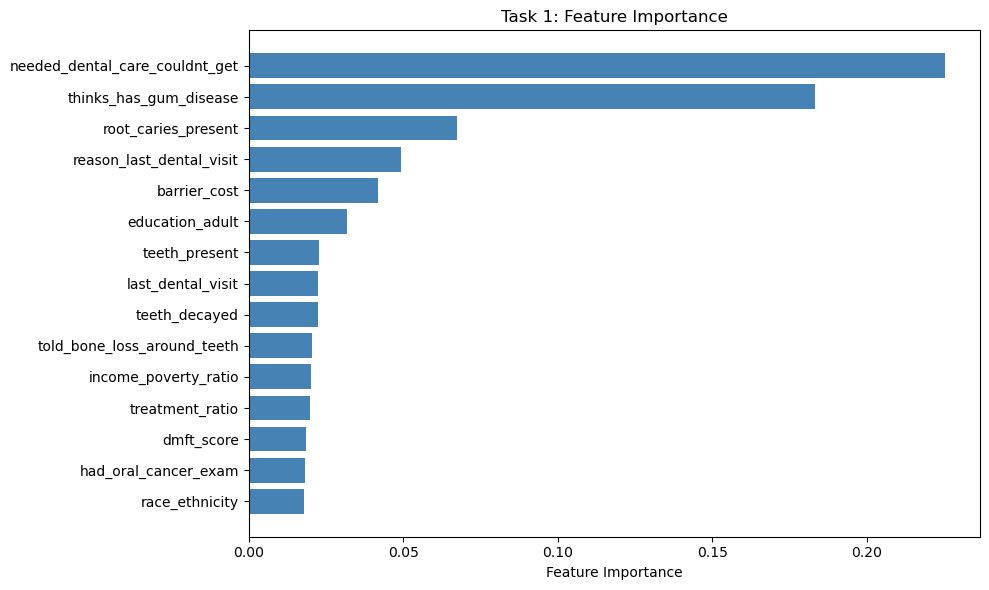

In [31]:
# fit XGBoost on full data for feature importance
xgb1 = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y1 == 0).sum() / (y1 == 1).sum(),
    eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
)
xgb1.fit(X1, y1)
plot_importance(xgb1, feat1, 'Task 1: Feature Importance')

### Hyperparameter Tuning for Task 1

In [36]:
# hyperparameter tuning for XGBoost using RandomizedSearchCV
# tune n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, and gamma
param_dist_clf = {
    'n_estimators': [200, 300, 500, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
}

# set up base XGBoost model with class imbalance handling for tuning
base_xgb1 = XGBClassifier(
    scale_pos_weight=(y1 == 0).sum() / (y1 == 1).sum(),
    eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
)
cv_strat1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# run randomized search CV
search1 = RandomizedSearchCV(
    base_xgb1, param_dist_clf,
    n_iter=40, scoring='roc_auc',
    cv=cv_strat1, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=0
)
search1.fit(X1, y1)

print(f'Best tuned CV AUC: {search1.best_score_:.4f}')
print(f'Best params: {search1.best_params_}')

# full report on tuned model
tuned_cv1 = cross_validate(
    search1.best_estimator_, X1, y1, cv=cv_strat1,
    scoring={'balanced_acc': 'balanced_accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1_weighted'}
)

best_xgb1 = search1.best_estimator_

Best tuned CV AUC: 0.8493
Best params: {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


## Task 2: Predict Need for Dental Care

`target_needs_care` (1 = clinician recommended any level of care during the NHANES exam)

In [20]:
X2, y2, feat2 = prepare_xy(FEATURES_TASK2, 'target_needs_care')
print(f'Positive rate: {y2.mean():.1%}')

models_clf2 = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y2 == 0).sum() / (y2 == 1).sum(),
        eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
    ),
}

print('\nTask 2 cross-validation (5-fold):')
results2 = run_cv(models_clf2, X2, y2, task='classification')
print(results2)

X shape: (5057, 36), y shape: (5057,), NaN remaining: 0
Positive rate: 42.5%

Task 2 cross-validation (5-fold):
  Fitting Logistic Regression... done
  Fitting Random Forest... done
  Fitting XGBoost... done
                           balanced_acc             roc_auc  \
model                                                         
Logistic Regression  0.7471 (+/-0.0121)  0.8313 (+/-0.0109)   
Random Forest        0.7403 (+/-0.0135)  0.8331 (+/-0.0107)   
XGBoost              0.7509 (+/-0.0176)  0.8398 (+/-0.0110)   

                                     f1  
model                                    
Logistic Regression  0.7547 (+/-0.0120)  
Random Forest        0.7546 (+/-0.0130)  
XGBoost              0.7584 (+/-0.0155)  


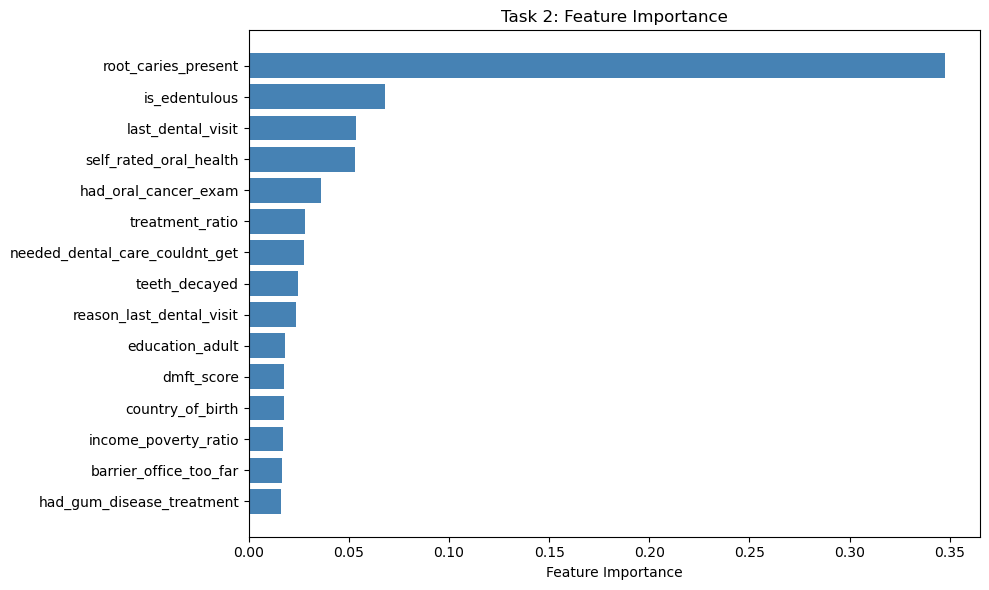

In [37]:
xgb2 = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y2 == 0).sum() / (y2 == 1).sum(),
    eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
)
xgb2.fit(X2, y2)
plot_importance(xgb2, feat2, 'Task 2: Feature Importance')

### Hyperparameter Tuning for Task 2

In [ ]:
base_xgb2 = XGBClassifier(
    scale_pos_weight=(y2 == 0).sum() / (y2 == 1).sum(),
    eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
)
cv_strat2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search2 = RandomizedSearchCV(
    base_xgb2, param_dist_clf,
    n_iter=40, scoring='roc_auc',
    cv=cv_strat2, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=0
)
search2.fit(X2, y2)

print(f'Best CV AUC (untuned): 0.8433')
print(f'Best CV AUC (tuned):   {search2.best_score_:.4f}')
print(f'Best params: {search2.best_params_}')

tuned_cv2 = cross_validate(
    search2.best_estimator_, X2, y2, cv=cv_strat2,
    scoring={'balanced_acc': 'balanced_accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1_weighted'}
)

best_xgb2 = search2.best_estimator_

Best CV AUC (untuned): 0.8433
Best CV AUC (tuned):   0.8440
Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}

Tuned XGBoost Task 2:
  balanced_acc    0.7572 (+/-0.0179)
  roc_auc         0.8440 (+/-0.0111)
  f1              0.7657 (+/-0.0164)


## Task 3: Predict DMFT Score

`dmft_score` (continuous, 0-28). DMFT counts Decayed + Missing (due to caries) + Filled teeth.

In [23]:
X3, y3, feat3 = prepare_xy(FEATURES_TASK3, 'dmft_score')
print(f'DMFT mean: {y3.mean():.2f}, std: {y3.std():.2f}, median: {np.median(y3):.1f}')
print(f'Naive MAE (predicting mean for everyone): {np.mean(np.abs(y3 - y3.mean())):.4f}')

models_reg = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mae', verbosity=0, random_state=RANDOM_STATE
    ),
}

print('\nTask 3 cross-validation (5-fold):')
results3 = run_cv(models_reg, X3, y3, task='regression')
print(results3)

X shape: (5265, 28), y shape: (5265,), NaN remaining: 0
DMFT mean: 10.74, std: 8.42, median: 9.0
Naive MAE (predicting mean for everyone): 6.9783

Task 3 cross-validation (5-fold):
  Fitting Ridge Regression... done
  Fitting Random Forest... done
  Fitting XGBoost... done
                                 mae                rmse                  r2
model                                                                       
Ridge Regression  5.0563 (+/-0.0951)  6.3934 (+/-0.1435)  0.4231 (+/-0.0231)
Random Forest     4.8330 (+/-0.0933)  6.2403 (+/-0.1283)  0.4505 (+/-0.0184)
XGBoost           4.7405 (+/-0.0879)  6.1423 (+/-0.1168)  0.4675 (+/-0.0208)


### Two-part DMFT Model

The single-stage regression has a structural problem. 385 of the 415 patients with dmft_score=28 are edentulous — they have no remaining natural teeth. For these patients, dmft=28 is essentially a deterministic outcome once you know they have no teeth, and asking a regression model to predict it from SES and behavioral features creates a difficult mixed task: partly predict continuous decay burden, partly predict complete tooth loss.

The two-stage approach splits this into two cleaner problems:
- **Part 1**: Binary classifier
  - predict whether a patient is edentulous (has no natural teeth). Uses the same SES, access, and behavioral features.
- **Part 2**: Regressor
  - predict DMFT score only for patients who have at least some teeth. This is a much simpler regression task because there is not a large cluster of data all evluating to 28 missing teeth.

In [40]:
# pair together
is_eden = df['is_edentulous'].values.astype(int)

kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_preds_2stage = np.zeros(len(y3))
fold_maes = []

# for each fold, predict edentulous status
# then regress DMFT only on non-edentulous rows
# combine predictions
for fold, (train_idx, test_idx) in enumerate(kf5.split(X3)):
    X_tr, X_te = X3[train_idx], X3[test_idx]
    y_tr, y_te = y3[train_idx], y3[test_idx]
    eden_tr = is_eden[train_idx]

    # Part1
    # predict edentulous on this fold's training data
    stage1 = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
    )
    stage1.fit(X_tr, eden_tr)
    eden_pred = stage1.predict(X_te)

    # Part2
    # regress DMFT only on non-edentulous rows
    not_eden_mask = eden_tr == 0
    stage2 = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mae', verbosity=0, random_state=RANDOM_STATE
    )
    stage2.fit(X_tr[not_eden_mask], y_tr[not_eden_mask])

    # combine
    # edentulous predicted are autoassigned 28
    # otherwise use regression output
    fold_preds = np.where(eden_pred == 1, 28.0, stage2.predict(X_te))
    all_preds_2stage[test_idx] = fold_preds
    fold_maes.append(mean_absolute_error(y_te, fold_preds))
    print(f'Fold {fold+1} MAE: {fold_maes[-1]:.4f}')

mae_2stage = mean_absolute_error(y3, all_preds_2stage)
rmse_2stage = np.sqrt(mean_squared_error(y3, all_preds_2stage))

ss_res = np.sum((y3 - all_preds_2stage) ** 2)
ss_tot = np.sum((y3 - y3.mean()) ** 2)
r2_2stage = 1 - ss_res / ss_tot

print(f'\nTwo-Part Model metrics:')
print(f'MAE: {mae_2stage:.4f}')
print(f'RMSE: {rmse_2stage:.4f}')
print(f'R2: {r2_2stage:.4f}')

Fold 1 MAE: 4.5635
Fold 2 MAE: 4.5348
Fold 3 MAE: 4.7808
Fold 4 MAE: 4.8179
Fold 5 MAE: 4.6385

Two-Part Model metrics:
MAE: 4.6671
RMSE: 6.3525
R2: 0.4313


#### Two-Part Model Feature Importances

Fitting both stages on the full dataset to see which features drive results at each stage. The Part 1 importances (edentulous rows) dominated by age mostlikley, since tooth loss happens over the years of one's life. The Part 2 importances (DMFT among people with teeth) show which SES and access features predict burden reagrdless of edentulous status.

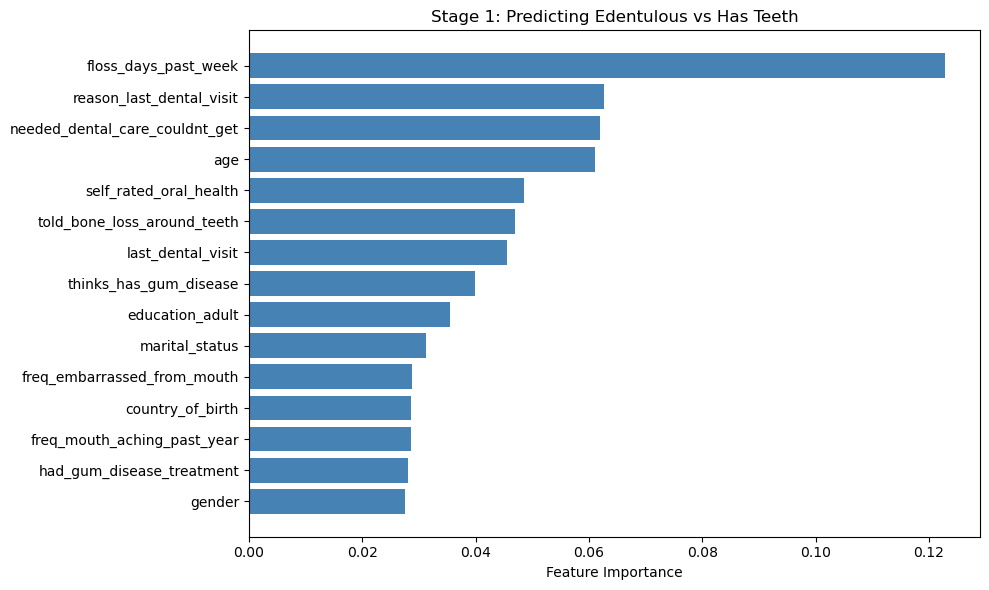

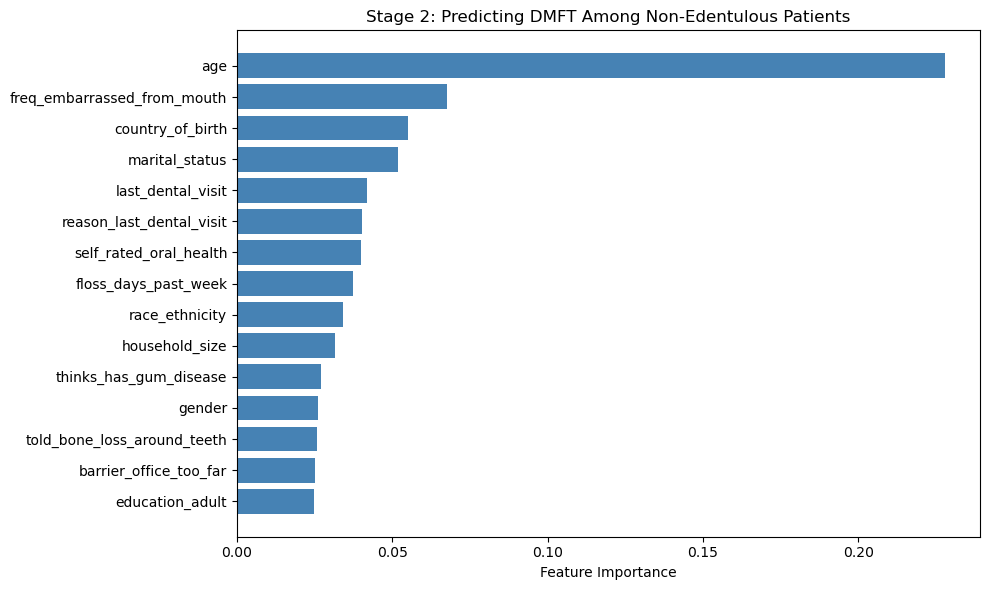

In [ ]:
# fit on full data for importance
stage1_full = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
)
stage1_full.fit(X3, is_eden)
plot_importance(stage1_full, feat3, 'Stage 1: Predicting Edentulous vs Has Teeth')

not_eden_all = is_eden == 0
stage2_full = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mae', verbosity=0, random_state=RANDOM_STATE
)
stage2_full.fit(X3[not_eden_all], y3[not_eden_all])
plot_importance(stage2_full, feat3, 'Stage 2: Predicting DMFT Among Non-Edentulous Individuals')

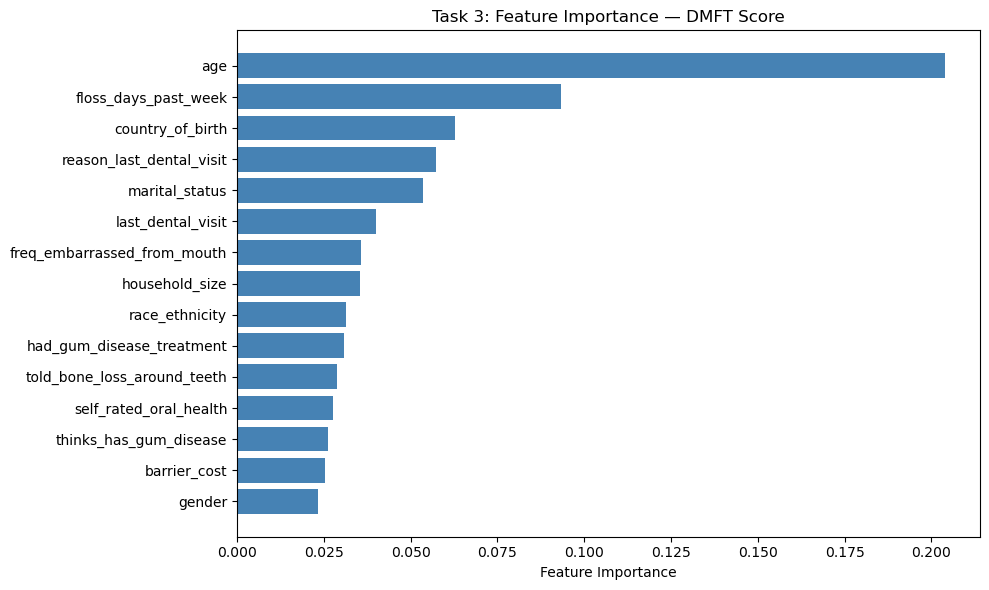

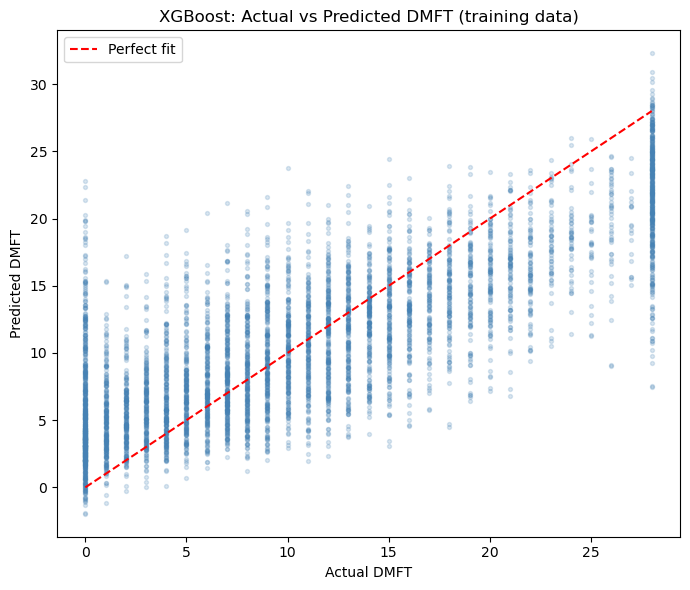

In [26]:
xgb3 = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mae', verbosity=0, random_state=RANDOM_STATE
)
xgb3.fit(X3, y3)
plot_importance(xgb3, feat3, 'Task 3: Feature Importance — DMFT Score')

# actual vs predicted scatter on full data (for visual check)
y3_pred = xgb3.predict(X3)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y3, y3_pred, alpha=0.2, s=8, color='steelblue')
lo, hi = 0, 28
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual DMFT')
ax.set_ylabel('Predicted DMFT')
ax.set_title('XGBoost: Actual vs Predicted DMFT (training data)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

In [42]:
print('Task 1: Predict Poor Self-Rated Oral Health')
print(results1.to_string())
print()
tuned1_bal = np.mean(tuned_cv1['test_balanced_acc'])
tuned1_auc = np.mean(tuned_cv1['test_roc_auc'])
tuned1_f1 = np.mean(tuned_cv1['test_f1'])
print(f'  Tuned XGBoost: balanced_acc={tuned1_bal:.4f}, roc_auc={tuned1_auc:.4f}, f1={tuned1_f1:.4f}')

print('\nTask 2: Predict Clinical Need for Dental Care')
print(results2.to_string())
print()
tuned2_bal = np.mean(tuned_cv2['test_balanced_acc'])
tuned2_auc = np.mean(tuned_cv2['test_roc_auc'])
tuned2_f1 = np.mean(tuned_cv2['test_f1'])
print(f'  Tuned XGBoost: balanced_acc={tuned2_bal:.4f}, roc_auc={tuned2_auc:.4f}, f1={tuned2_f1:.4f}')

print('\nTask 3: Predict DMFT Score')
print(results3.to_string())
print(f'  Two-Stage XGBoost: MAE={mae_2stage:.4f}, RMSE={rmse_2stage:.4f}, R2={r2_2stage:.4f}')
print(f'  Naive baseline (predict mean): MAE={np.mean(np.abs(y3 - y3.mean())):.4f}')

Task 1: Predict Poor Self-Rated Oral Health
                           balanced_acc             roc_auc                  f1
model                                                                          
Logistic Regression  0.7550 (+/-0.0030)  0.8410 (+/-0.0042)  0.7684 (+/-0.0042)
Random Forest        0.7348 (+/-0.0050)  0.8430 (+/-0.0068)  0.7773 (+/-0.0057)
XGBoost              0.7600 (+/-0.0073)  0.8382 (+/-0.0062)  0.7755 (+/-0.0075)

  Tuned XGBoost: balanced_acc=0.7703, roc_auc=0.8493, f1=0.7785

Task 2: Predict Clinical Need for Dental Care
                           balanced_acc             roc_auc                  f1
model                                                                          
Logistic Regression  0.7471 (+/-0.0121)  0.8313 (+/-0.0109)  0.7547 (+/-0.0120)
Random Forest        0.7403 (+/-0.0135)  0.8331 (+/-0.0107)  0.7546 (+/-0.0130)
XGBoost              0.7509 (+/-0.0176)  0.8398 (+/-0.0110)  0.7584 (+/-0.0155)

  Tuned XGBoost: balanced_acc=0.7572, roc_a